# 02 — Exploratory Data Analysis

This notebook explores the chemical and bioactivity characteristics of the prepared human Nav1.7 dataset generated in `01_data_preparation.ipynb`.

Only compounds classified as `GOOD` during data preparation are included in the primary exploratory analysis. These compounds have a max/min IC50 ratio below 3. Confidence levels (`HIGH`, `MEDIUM`, and `LOW`) are retained to distinguish compounds according to the number of available measurements.

### Goals

The exploratory analysis will examine:

1. The distribution of Nav1.7 inhibitory activity using IC50 and pIC50
2. The distribution of molecular properties such as molecular weight
3. The number of IC50 measurements available per compound
4. Differences among confidence levels
5. Relationships between molecular properties and Nav1.7 activity
6. The chemical and activity space represented by the prepared dataset

The purpose of this notebook is to characterize the dataset, identify important patterns and limitations, and provide context for the machine-learning analysis performed in `03_machine_learning_models.ipynb`.

## 1. Setup and Load Prepared Data

This notebook uses the `GOOD` compound dataset generated in `01_data_preparation.ipynb`.

The dataset contains compounds whose available IC50 measurements have a max/min ratio below 3. The associated confidence levels are retained to distinguish compounds according to the number of supporting measurements.

The prepared CSV file is uploaded and loaded without repeating the filtering and structure-cleaning procedures performed in the previous notebook.

In [3]:
%pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 48.5 MB/s eta 0:00:00


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from rdkit import Chem
from rdkit.Chem import Descriptors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
from google.colab import files

# Upload the GOOD dataset generated in 01_data_preparation.ipynb
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

good_df = pd.read_csv(file_name)

print(f"Loaded: {file_name}")
print(f"Compounds: {len(good_df):,}")
print(f"Columns: {len(good_df.columns)}")

display(good_df.head())

Saving nav17_good.csv to nav17_good.csv
Loaded: nav17_good.csv
Compounds: 6,738
Columns: 11


,molecule_chembl_id,canonical_smiles,molecular_weight,ic50_nm,pIC50,min_val,max_val,measurement_count,max_min_ratio,data_quality,confidence_level
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,400.164774,990.0,6.004365,990.0,990.0,1,1.000000,GOOD,LOW
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,462.198857,6.0,8.221849,6.0,6.0,1,1.000000,GOOD,LOW
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,314.224580,1820.0,5.739929,1820.0,1820.0,1,1.000000,GOOD,LOW
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,413.086783,2420.0,5.616185,2420.0,2420.0,1,1.000000,GOOD,LOW
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,416.188212,51.1,7.291579,51.0,51.2,2,1.003922,GOOD,MEDIUM


In [6]:
# Verify that only GOOD records are present
print(good_df['data_quality'].value_counts())

assert (good_df['data_quality'] == 'GOOD').all(), \
    "Dataset contains records not classified as GOOD."

data_quality
GOOD    6738
Name: count, dtype: int64


## 2. Nav1.7 Potency Distribution

To characterize the range of inhibitory activities represented in the dataset, compounds are grouped into four potency classes based on their median IC50 values:

- **Very Potent:** IC50 ≤ 10 nM
- **Potent:** IC50 > 10 to ≤ 100 nM
- **Medium:** IC50 > 100 to ≤ 1000 nM
- **Weak:** IC50 > 1000 nM (1 µM)

These categories provide an interpretable overview of the activity range represented in the dataset before examining the continuous IC50 and pIC50 distributions.

In [7]:
# Define IC50 potency bins in nM
bins = [0, 10, 100, 1000, np.inf]

labels = [
    'Very Potent (≤10 nM)',
    'Potent (>10–100 nM)',
    'Medium (>100–1000 nM)',
    'Weak (>1000 nM)'
]

# Assign potency class based on median IC50
good_df['potency_class'] = pd.cut(
    good_df['ic50_nm'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Count compounds in each potency class
potency_counts = (
    good_df['potency_class']
    .value_counts(sort=False)
)

print("--- Potency Classification ---")
print(potency_counts)

--- Potency Classification ---
potency_class
Very Potent (≤10 nM)      582
Potent (>10–100 nM)      1666
Medium (>100–1000 nM)    2232
Weak (>1000 nM)          2258
Name: count, dtype: int64


## 3. Distribution of Nav1.7 Inhibitory Activity

The distribution of pIC50 values is examined to characterize the range of Nav1.7 inhibitory activities represented in the prepared dataset.

pIC50 expresses inhibitory potency on a logarithmic scale, where higher values indicate greater potency. For reference:

- **pIC50 = 6** corresponds to an IC50 of 1 µM (1000 nM)
- **pIC50 = 8** corresponds to an IC50 of 10 nM

A bin width of 0.5 pIC50 units is used to visualize the activity distribution while maintaining sufficient resolution to identify broad patterns in the dataset.

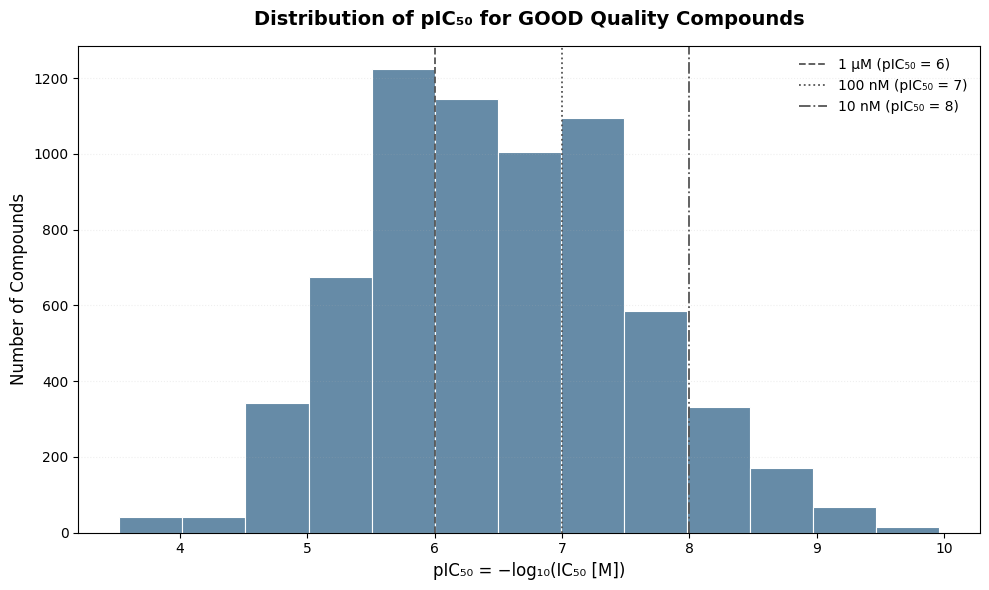

In [8]:
import seaborn as sns

# Plot pIC₅₀ distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='pIC50',
    binwidth=0.5,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Potency-class reference lines
plt.axvline(
    x=6.0,
    color='#555555',
    linestyle='--',
    linewidth=1.3,
    label='1 µM (pIC₅₀ = 6)'
)

plt.axvline(
    x=7.0,
    color='#555555',
    linestyle=':',
    linewidth=1.3,
    label='100 nM (pIC₅₀ = 7)'
)

plt.axvline(
    x=8.0,
    color='#555555',
    linestyle='-.',
    linewidth=1.3,
    label='10 nM (pIC₅₀ = 8)'
)

# Formatting
plt.title(
    'Distribution of pIC₅₀ for GOOD Quality Compounds',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### pIC₅₀ Distribution Summary

To complement the histogram, the pIC₅₀ values are summarized using the same 0.5-unit intervals used in the visualization. Compound counts within each interval provide the numerical distribution underlying the histogram.

Basic descriptive statistics are also reported to characterize the overall range and central tendency of Nav1.7 inhibitory activity in the prepared dataset.

In [9]:
# Determine the pIC₅₀ range and construct 0.5-unit bins
min_p = np.floor(good_df['pIC50'].min() * 2) / 2
max_p = np.ceil(good_df['pIC50'].max() * 2) / 2

bin_edges = np.arange(
    min_p,
    max_p + 0.5,
    0.5
)

# Bin pIC₅₀ values and count compounds
binned_data = pd.cut(
    good_df['pIC50'],
    bins=bin_edges,
    right=False
)

raw_counts = (
    binned_data
    .value_counts()
    .sort_index()
)

# Display histogram-bin counts
print("--- pIC₅₀ Histogram Bin Counts ---")
print(f"{'pIC₅₀ Range':<20} | {'Compound Count':<15}")
print("-" * 38)

for bin_interval, count in raw_counts.items():
    interval_str = (
        f"[{bin_interval.left:.1f}, "
        f"{bin_interval.right:.1f})"
    )
    print(f"{interval_str:<20} | {count:<15}")


# Display summary statistics
print("\n--- pIC₅₀ Summary Statistics ---")

print(f"Total Compounds: {len(good_df):,}")
print(f"Minimum pIC₅₀:   {good_df['pIC50'].min():.2f}")
print(f"Median pIC₅₀:    {good_df['pIC50'].median():.2f}")
print(f"Maximum pIC₅₀:   {good_df['pIC50'].max():.2f}")
print(f"Mean pIC₅₀:      {good_df['pIC50'].mean():.2f}")
print(f"Std. Dev.:       {good_df['pIC50'].std():.2f}")

--- pIC₅₀ Histogram Bin Counts ---
pIC₅₀ Range          | Compound Count 
--------------------------------------
[3.5, 4.0)           | 39             
[4.0, 4.5)           | 42             
[4.5, 5.0)           | 289            
[5.0, 5.5)           | 717            
[5.5, 6.0)           | 1171           
[6.0, 6.5)           | 1213           
[6.5, 7.0)           | 1019           
[7.0, 7.5)           | 1098           
[7.5, 8.0)           | 568            
[8.0, 8.5)           | 340            
[8.5, 9.0)           | 164            
[9.0, 9.5)           | 67             
[9.5, 10.0)          | 11             

--- pIC₅₀ Summary Statistics ---
Total Compounds: 6,738
Minimum pIC₅₀:   3.53
Median pIC₅₀:    6.46
Maximum pIC₅₀:   9.96
Mean pIC₅₀:      6.51
Std. Dev.:       1.03


### Initial Observation

The GOOD dataset contains 6,738 unique molecular structures spanning a broad range of Nav1.7 inhibitory activities (pIC₅₀ = 3.53–9.96).

The activity distribution is centered near pIC₅₀ 6.5, with a mean of 6.51 and median of 6.46. Most compounds fall within approximately pIC₅₀ 5–8, while relatively few compounds occur at the extreme low- and high-potency ends of the distribution.

The broad activity range provides a useful basis for subsequent investigation of relationships between molecular structure and Nav1.7 inhibitory potency.

## 4. Molecular Weight Distribution

Molecular weight is examined to characterize the molecular size range represented in the Nav1.7 dataset.

The prepared dataset was restricted to compounds with molecular weights between 100 and 1000 Da during data preparation. Here, the distribution within that range is examined using 50 Da intervals.

A reference line at 500 Da indicates the molecular-weight criterion commonly associated with Lipinski's Rule of Five. This threshold is shown as a reference for drug-like chemical space rather than as an additional filtering criterion.

Missing molecular weights: 0


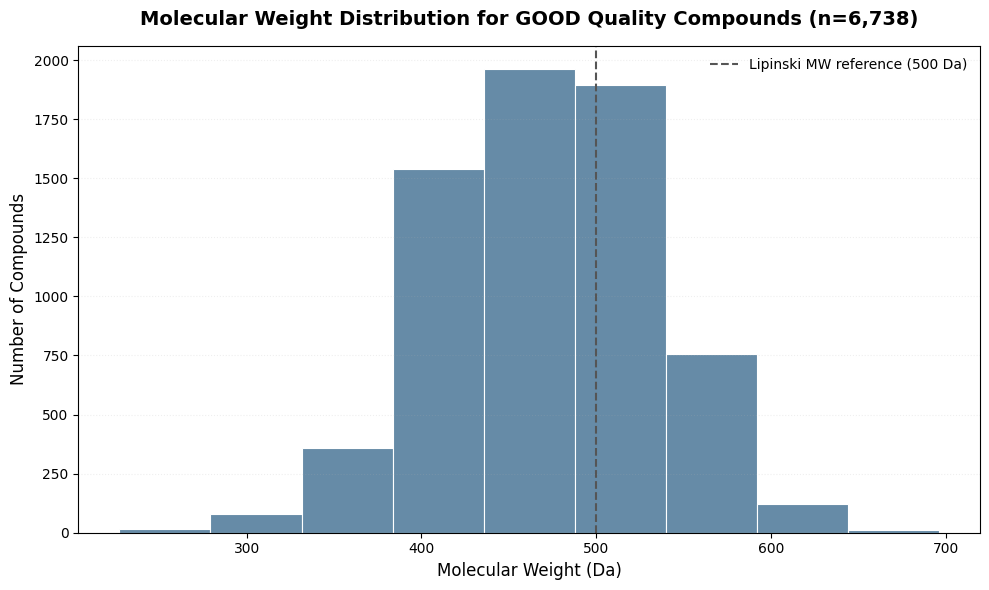

In [10]:
# Verify that molecular-weight data are complete
print(
    f"Missing molecular weights: "
    f"{good_df['molecular_weight'].isna().sum()}"
)

# Plot molecular-weight distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='molecular_weight',
    binwidth=50,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Lipinski Rule-of-Five reference
plt.axvline(
    x=500,
    color='#555555',
    linestyle='--',
    linewidth=1.5,
    label='Lipinski MW reference (500 Da)'
)

plt.title(
    f'Molecular Weight Distribution for GOOD Quality Compounds '
    f'(n={len(good_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Molecular Weight Summary

Descriptive statistics are calculated to summarize the molecular-weight distribution. The proportion of compounds above 500 Da is also reported to provide context relative to the molecular-weight criterion commonly associated with Lipinski's Rule of Five.

In [11]:
# Calculate molecular-weight summary statistics
mw_mean = good_df['molecular_weight'].mean()
mw_median = good_df['molecular_weight'].median()
mw_std = good_df['molecular_weight'].std()
mw_min = good_df['molecular_weight'].min()
mw_max = good_df['molecular_weight'].max()

# Calculate compounds above the 500 Da Lipinski reference
above_500 = (good_df['molecular_weight'] > 500).sum()
above_500_pct = above_500 / len(good_df) * 100


# Display summary
print("--- Molecular Weight Summary Statistics ---")

print(f"Total Compounds:     {len(good_df):,}")
print(f"Minimum MW:          {mw_min:.2f} Da")
print(f"Mean MW:             {mw_mean:.2f} Da")
print(f"Median MW:           {mw_median:.2f} Da")
print(f"Maximum MW:          {mw_max:.2f} Da")
print(f"Std. Dev.:           {mw_std:.2f} Da")

print("\n--- Lipinski MW Reference ---")

print(f"Compounds ≤500 Da:   {len(good_df) - above_500:,}")
print(f"Compounds >500 Da:   {above_500:,}")
print(f"Percent >500 Da:     {above_500_pct:.1f}%")

--- Molecular Weight Summary Statistics ---
Total Compounds:     6,738
Minimum MW:          227.11 Da
Mean MW:             472.17 Da
Median MW:           472.07 Da
Maximum MW:          696.24 Da
Std. Dev.:           61.67 Da

--- Lipinski MW Reference ---
Compounds ≤500 Da:   4,368
Compounds >500 Da:   2,370
Percent >500 Da:     35.2%


### Initial Observation

The 6,738 compounds have a mean molecular weight of 472.17 Da and a median of 472.07 Da, indicating that the distribution is centered near 470 Da. The observed molecular-weight range (227.11–696.24 Da) is substantially narrower than the 100–1000 Da range permitted during data preparation.

Most compounds (64.8%) have molecular weights at or below the 500 Da Lipinski reference, while 35.2% exceed this threshold. The 500 Da value is used here only as a reference for molecular size and is not treated as an exclusion criterion.

## 5. Lipophilicity (LogP) Distribution

Lipophilicity is examined using the calculated octanol/water partition coefficient (LogP), a molecular property related to the balance between hydrophobic and hydrophilic character.

LogP is calculated from each compound's canonical SMILES using RDKit. The distribution is visualized using 0.5-unit intervals.

A reference line at LogP = 5 indicates the lipophilicity criterion commonly associated with Lipinski's Rule of Five. This value is shown for context and is not used as an additional filtering criterion.

In [12]:
# Calculate RDKit LogP from canonical SMILES
def calculate_logp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.nan

    return Descriptors.MolLogP(mol)


good_df['logp'] = (
    good_df['canonical_smiles']
    .apply(calculate_logp)
)

# Check for failed calculations
missing_logp = good_df['logp'].isna().sum()

print(f"LogP values calculated: {good_df['logp'].notna().sum():,}")
print(f"Missing LogP values:    {missing_logp:,}")

LogP values calculated: 6,738
Missing LogP values:    0


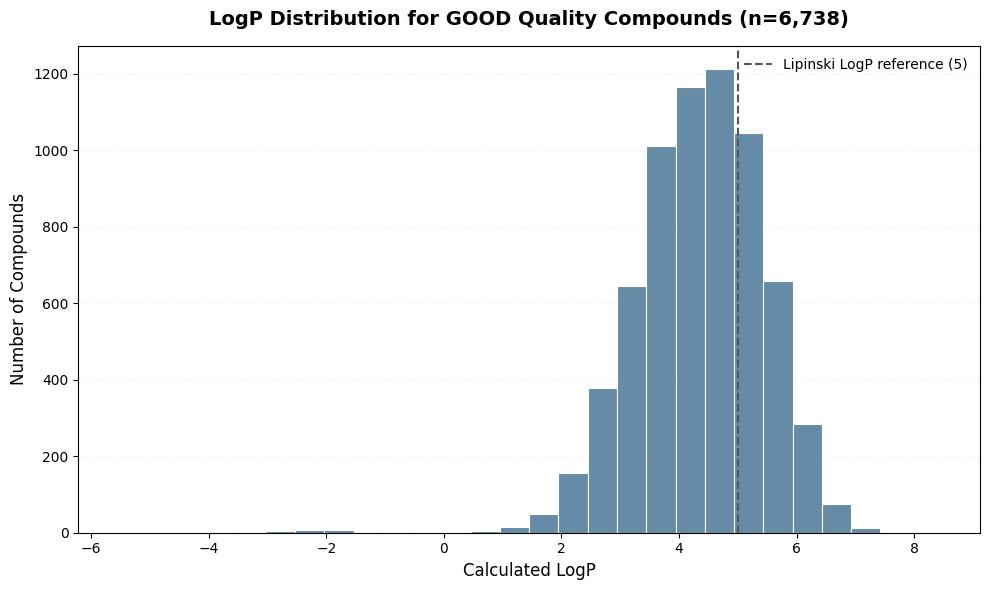

In [13]:
# Plot LogP distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=good_df,
    x='logp',
    binwidth=0.5,
    kde=False,
    color='#33658A',
    edgecolor='white',
    linewidth=0.8
)

# Lipinski Rule-of-Five reference
plt.axvline(
    x=5.0,
    color='#555555',
    linestyle='--',
    linewidth=1.5,
    label='Lipinski LogP reference (5)'
)

plt.title(
    f'LogP Distribution for GOOD Quality Compounds '
    f'(n={good_df["logp"].notna().sum():,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Calculated LogP',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [14]:
# Calculate LogP summary statistics
logp_data = good_df['logp'].dropna()

above_5 = (logp_data > 5).sum()
above_5_pct = above_5 / len(logp_data) * 100

print("--- LogP Summary Statistics ---")

print(f"Total Compounds:     {len(logp_data):,}")
print(f"Minimum LogP:        {logp_data.min():.2f}")
print(f"Mean LogP:           {logp_data.mean():.2f}")
print(f"Median LogP:         {logp_data.median():.2f}")
print(f"Maximum LogP:        {logp_data.max():.2f}")
print(f"Std. Dev.:           {logp_data.std():.2f}")

print("\n--- Lipinski LogP Reference ---")

print(f"Compounds ≤5:        {len(logp_data) - above_5:,}")
print(f"Compounds >5:        {above_5:,}")
print(f"Percent >5:          {above_5_pct:.1f}%")

--- LogP Summary Statistics ---
Total Compounds:     6,738
Minimum LogP:        -5.52
Mean LogP:           4.35
Median LogP:         4.40
Maximum LogP:        8.42
Std. Dev.:           1.10

--- Lipinski LogP Reference ---
Compounds ≤5:        4,797
Compounds >5:        1,941
Percent >5:          28.8%


### Initial Observation

The 6,738 compounds have a mean calculated LogP of 4.35 and a median of 4.40, indicating that the dataset is centered toward relatively lipophilic chemical space.

Most compounds (71.2%) have calculated LogP values at or below the Lipinski reference of 5, while 28.8% exceed this value. The distribution is concentrated primarily around LogP values of approximately 3–6, although a small number of compounds extend into substantially more hydrophilic or lipophilic regions.

As with molecular weight, the Lipinski threshold is used only as a reference for describing the chemical space and is not treated as an exclusion criterion.

## 6. Measurement Count and Experimental Support

The number of IC₅₀ measurements available for each compound is examined to characterize the amount of experimental evidence supporting the representative median IC₅₀ value.

Compounds with repeated measurements provide greater opportunity to assess measurement agreement, while compounds represented by a single measurement have more limited experimental support.

These measurement counts form the basis of the confidence classifications defined during data preparation:

- **HIGH:** 3 or more measurements
- **MEDIUM:** 2 measurements
- **LOW:** 1 measurement

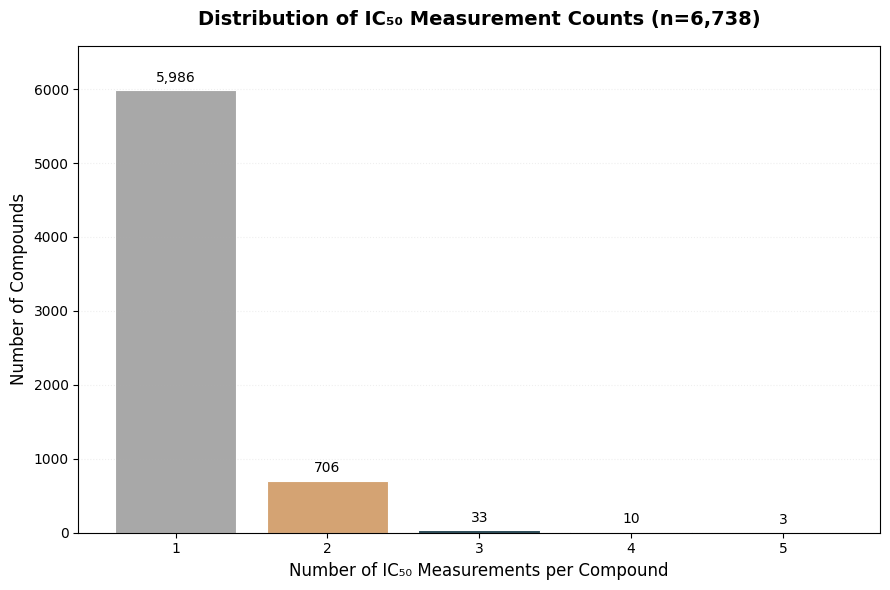

In [15]:
# Count compounds by number of IC₅₀ measurements
mc_counts = (
    good_df['measurement_count']
    .value_counts()
    .sort_index()
)

# Assign colors according to confidence level
bar_colors = [
    '#A8A8A8' if n == 1 else       # LOW
    '#D4A373' if n == 2 else       # MEDIUM
    '#264653'                       # HIGH
    for n in mc_counts.index
]

# Create bar plot
plt.figure(figsize=(9, 6))

ax = plt.bar(
    mc_counts.index,
    mc_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Add compound counts above each bar
for bar in ax:
    height = bar.get_height()

    plt.annotate(
        f'{int(height):,}',
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Formatting
plt.title(
    f'Distribution of IC₅₀ Measurement Counts '
    f'(n={len(good_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Number of IC₅₀ Measurements per Compound',
    fontsize=12
)

plt.ylabel(
    'Number of Compounds',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.ylim(
    0,
    mc_counts.max() * 1.10
)

plt.tight_layout()
plt.show()

In [16]:
# Summarize compounds by confidence level
confidence_counts = (
    good_df['confidence_level']
    .value_counts()
    .reindex(['LOW', 'MEDIUM', 'HIGH'])
)

confidence_pct = (
    confidence_counts / len(good_df) * 100
)

print("--- Experimental Confidence Summary ---")

for level in ['LOW', 'MEDIUM', 'HIGH']:
    print(
        f"{level:<6}: "
        f"{confidence_counts[level]:>5,} compounds "
        f"({confidence_pct[level]:.1f}%)"
    )

--- Experimental Confidence Summary ---
LOW   : 5,986 compounds (88.8%)
MEDIUM:   706 compounds (10.5%)
HIGH  :    46 compounds (0.7%)


### Initial Observation

Most compounds in the GOOD dataset are supported by a single IC₅₀ measurement. Of the 6,738 compounds, 5,986 (88.8%) are classified as LOW confidence, while 706 (10.5%) are supported by two measurements and classified as MEDIUM confidence. Only 46 compounds (0.7%) have three or more measurements and are classified as HIGH confidence.

Therefore, although all compounds in the dataset satisfy the GOOD data-quality criterion, the amount of experimental support varies substantially. In particular, the GOOD classification of single-measurement compounds reflects the absence of observed disagreement rather than demonstrated reproducibility.

This limitation should be considered when interpreting subsequent exploratory analyses and machine-learning results.

## 7. Relationship Between Lipophilicity and Nav1.7 Potency

To investigate whether lipophilicity is associated with Nav1.7 inhibitory activity, calculated LogP is compared with pIC₅₀.

Two correlation measures are reported:

- **Pearson correlation (r):** measures the strength of a linear relationship between LogP and pIC₅₀.
- **Spearman correlation (ρ):** measures the strength of a monotonic relationship and is less sensitive to non-normal distributions and extreme values.

A linear regression line is included to visualize the overall trend. Because the dataset contains a large number of compounds, correlation magnitude and the visible pattern are considered alongside statistical significance.

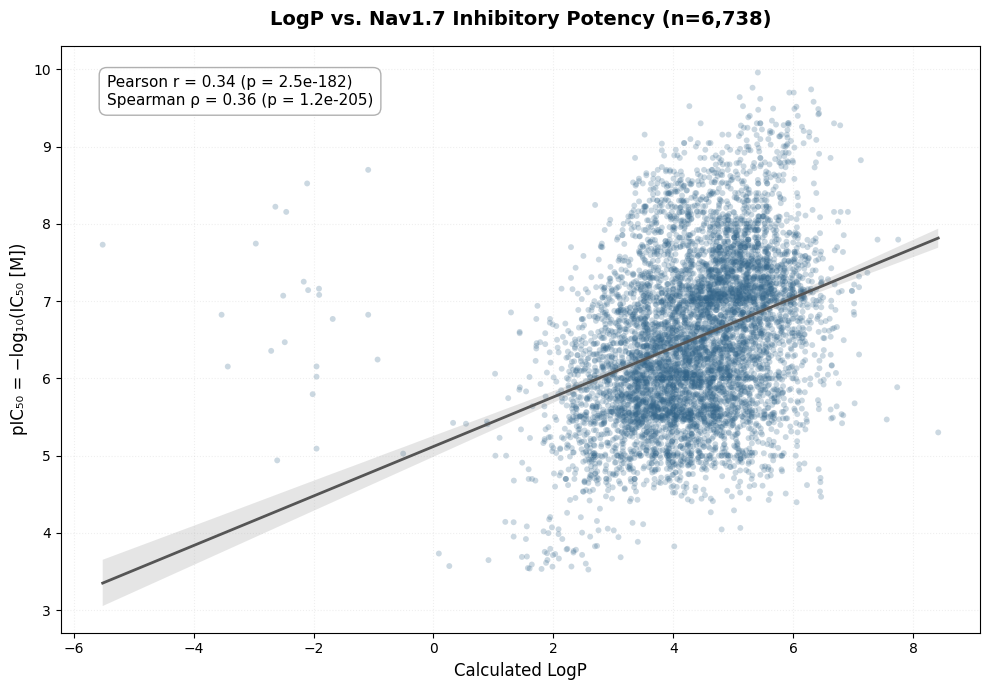

--- LogP vs. pIC₅₀ Correlation ---
Pearson r:    0.340
Pearson p:    2.475e-182
Spearman ρ:   0.360
Spearman p:   1.198e-205


In [17]:
# Remove rows with missing LogP or pIC₅₀ values
property_df = good_df.dropna(
    subset=['logp', 'pIC50']
).copy()


# Calculate Pearson and Spearman correlations
pearson_r, p_pearson = stats.pearsonr(
    property_df['logp'],
    property_df['pIC50']
)

spearman_rho, p_spearman = stats.spearmanr(
    property_df['logp'],
    property_df['pIC50']
)


# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=property_df,
    x='logp',
    y='pIC50',
    color='#33658A',
    alpha=0.25,
    edgecolor='none',
    s=18
)

# Add linear trend line
sns.regplot(
    data=property_df,
    x='logp',
    y='pIC50',
    scatter=False,
    color='#555555',
    line_kws={
        'linewidth': 2,
        'linestyle': '-'
    }
)


# Add correlation statistics
stats_text = (
    f"Pearson r = {pearson_r:.2f} (p = {p_pearson:.1e})\n"
    f"Spearman ρ = {spearman_rho:.2f} (p = {p_spearman:.1e})"
)

plt.gca().text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#A8A8A8'
    )
)


# Formatting
plt.title(
    f'LogP vs. Nav1.7 Inhibitory Potency (n={len(property_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Calculated LogP',
    fontsize=12
)

plt.ylabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# Print numerical results
print("--- LogP vs. pIC₅₀ Correlation ---")
print(f"Pearson r:    {pearson_r:.3f}")
print(f"Pearson p:    {p_pearson:.3e}")
print(f"Spearman ρ:   {spearman_rho:.3f}")
print(f"Spearman p:   {p_spearman:.3e}")

### Initial Observation

Calculated LogP shows a moderate positive association with Nav1.7 inhibitory potency. Pearson correlation gives **r = 0.34**, while Spearman correlation gives **ρ = 0.36**. Both correlations are statistically significant (p < 10⁻¹⁸⁰).

The similar Pearson and Spearman coefficients indicate that the observed positive association is not limited to a strictly linear relationship and is broadly preserved when compounds are ranked by LogP and potency.

Overall, compounds with higher calculated lipophilicity tend to exhibit higher pIC₅₀ values, corresponding to greater Nav1.7 inhibitory potency. However, the substantial spread in pIC₅₀ at similar LogP values shows that lipophilicity alone does not determine activity.

Because of the large dataset size (n = 6,738), the very small p-values should not be interpreted as evidence of a strong relationship. The correlation coefficients indicate that the magnitude of the association is moderate.

## 8. Lipophilicity Across Potency Classes

To further examine the relationship between lipophilicity and Nav1.7 inhibitory activity, calculated LogP values are compared across the four potency classes defined earlier:

- **Weak:** IC₅₀ > 1000 nM
- **Medium:** IC₅₀ > 100 to ≤ 1000 nM
- **Potent:** IC₅₀ > 10 to ≤ 100 nM
- **Very Potent:** IC₅₀ ≤ 10 nM

Box plots show the distribution of calculated LogP within each potency class. The center line represents the median, while the mean is shown separately as a white circular marker.

This comparison complements the continuous correlation analysis by showing how the distribution of lipophilicity changes across interpretable activity categories.

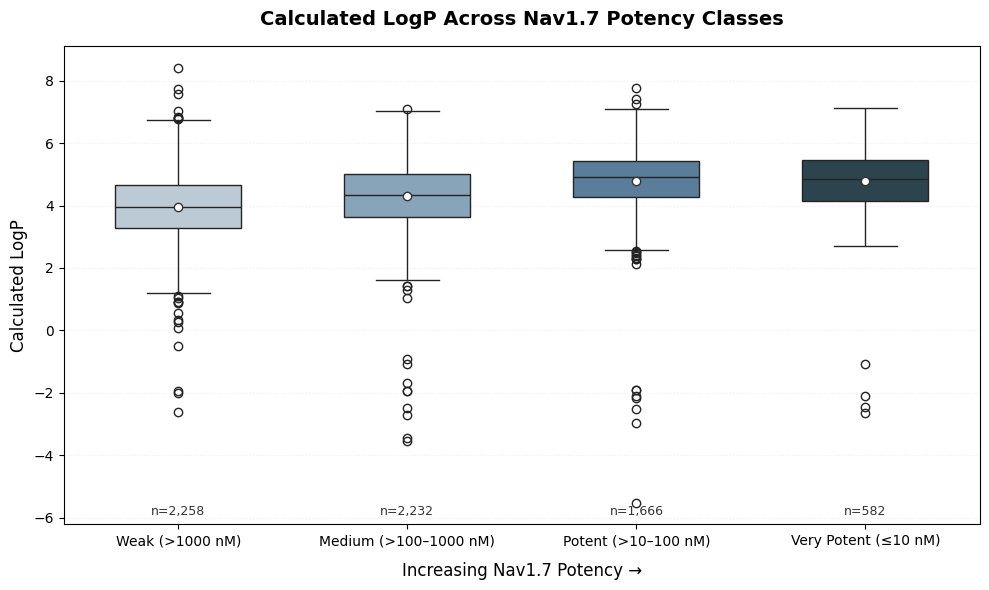

In [18]:
# Remove records missing LogP or potency classification
potency_logp_df = good_df.dropna(
    subset=['logp', 'potency_class']
).copy()

# Maintain the potency order defined previously
potency_order = [
    'Weak (>1000 nM)',
    'Medium (>100–1000 nM)',
    'Potent (>10–100 nM)',
    'Very Potent (≤10 nM)'
]

# Sequential blue palette: increasing potency
potency_colors = [
    '#B8CBD9',
    '#7FA6C0',
    '#4F7FA3',
    '#264653'
]

# Create box plot
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=potency_logp_df,
    x='potency_class',
    y='logp',
    order=potency_order,
    hue='potency_class',
    palette=dict(zip(potency_order, potency_colors)),
    legend=False,
    width=0.55,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#333333',
        'markersize': 6
    }
)

# Add sample size beneath each category
group_counts = (
    potency_logp_df['potency_class']
    .value_counts()
)

y_min, y_max = ax.get_ylim()

for i, category in enumerate(potency_order):
    count = group_counts.get(category, 0)

    ax.text(
        i,
        y_min + 0.2,
        f'n={count:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333333'
    )

# Formatting
plt.title(
    'Calculated LogP Across Nav1.7 Potency Classes',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Increasing Nav1.7 Potency →',
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    'Calculated LogP',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

In [19]:
# Calculate LogP summary statistics by potency class
summary_stats = (
    potency_logp_df
    .groupby('potency_class', observed=False)['logp']
    .describe(percentiles=[0.25, 0.50, 0.75])
)

print("--- LogP Summary by Potency Class ---")

for category in potency_order:
    row = summary_stats.loc[category]

    median_val = row['50%']
    q25 = row['25%']
    q75 = row['75%']

    print(
        f"{category}: "
        f"median {median_val:.2f}, "
        f"IQR {q25:.2f}–{q75:.2f}"
    )

--- LogP Summary by Potency Class ---
Weak (>1000 nM): median 3.95, IQR 3.27–4.65
Medium (>100–1000 nM): median 4.34, IQR 3.63–5.02
Potent (>10–100 nM): median 4.90, IQR 4.27–5.42
Very Potent (≤10 nM): median 4.85, IQR 4.16–5.45


### Initial Observation

Calculated LogP generally increases with Nav1.7 inhibitory potency from the Weak through Potent classes. Median LogP increases from 3.95 for Weak compounds to 4.34 for Medium compounds and 4.90 for Potent compounds.

However, this trend does not continue in the Very Potent class, which has a slightly lower median LogP of 4.85. The Potent and Very Potent groups also have strongly overlapping interquartile ranges (4.27–5.42 and 4.16–5.45, respectively).

These results suggest that the positive relationship between lipophilicity and potency may not continue indefinitely. Instead, the association appears to plateau around the LogP range represented by the Potent and Very Potent compounds. This pattern is consistent with the possibility that lipophilicity has a favorable range rather than a simple “higher is better” relationship.

Further analysis is required before interpreting this pattern as evidence of an optimal LogP, since potency depends on multiple molecular and structural properties and the present analysis is observational.

## 9. Relationship Between Molecular Weight and Nav1.7 Potency

To examine whether molecular size is associated with Nav1.7 inhibitory activity, molecular weight is compared with pIC₅₀.

As in the LogP analysis, both Pearson and Spearman correlations are calculated:

- **Pearson correlation (r):** measures the strength of the linear relationship between molecular weight and pIC₅₀.
- **Spearman correlation (ρ):** measures the strength of the monotonic relationship based on ranked values.

A linear regression line is included to visualize the overall trend. Correlation magnitude and the distribution of individual compounds are considered alongside statistical significance.

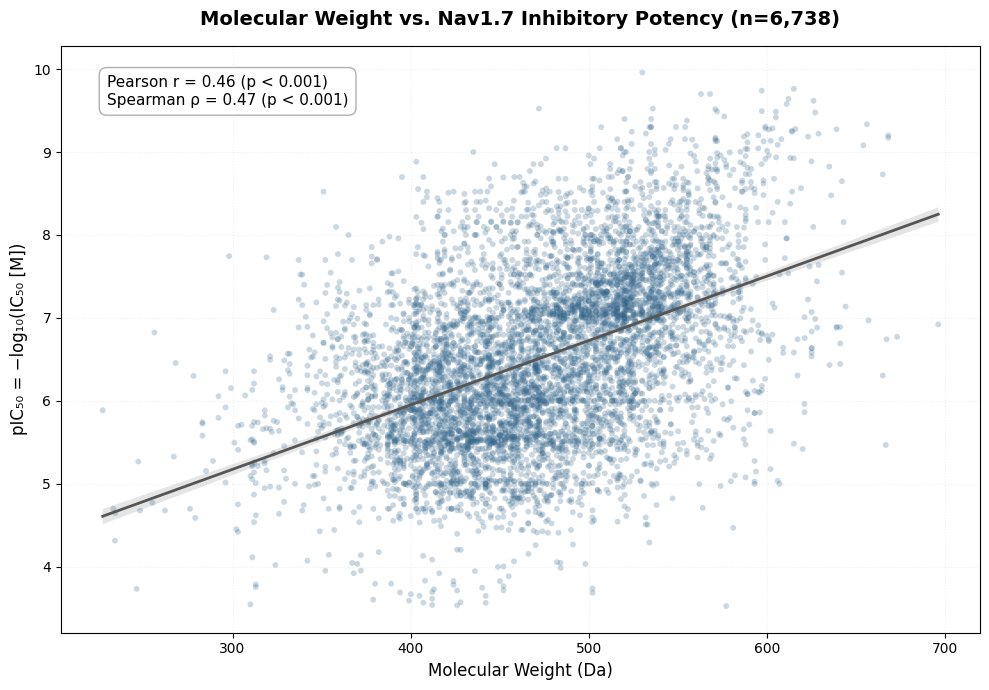

--- Molecular Weight vs. pIC₅₀ Correlation ---
Pearson r:    0.464
Pearson p:    0.000e+00
Spearman ρ:   0.468
Spearman p:   0.000e+00


In [20]:
# Remove rows with missing molecular weight or pIC₅₀
mw_activity_df = good_df.dropna(
    subset=['molecular_weight', 'pIC50']
).copy()


# Calculate Pearson and Spearman correlations
pearson_r, p_pearson = stats.pearsonr(
    mw_activity_df['molecular_weight'],
    mw_activity_df['pIC50']
)

spearman_rho, p_spearman = stats.spearmanr(
    mw_activity_df['molecular_weight'],
    mw_activity_df['pIC50']
)


# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mw_activity_df,
    x='molecular_weight',
    y='pIC50',
    color='#33658A',
    alpha=0.25,
    edgecolor='none',
    s=18
)

# Add linear trend line
sns.regplot(
    data=mw_activity_df,
    x='molecular_weight',
    y='pIC50',
    scatter=False,
    color='#555555',
    line_kws={
        'linewidth': 2,
        'linestyle': '-'
    }
)


# Add correlation statistics
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

stats_text = (
    f"Pearson r = {pearson_r:.2f} ({format_p(p_pearson)})\n"
    f"Spearman ρ = {spearman_rho:.2f} ({format_p(p_spearman)})"
)

plt.gca().text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#A8A8A8'
    )
)


# Formatting
plt.title(
    f'Molecular Weight vs. Nav1.7 Inhibitory Potency '
    f'(n={len(mw_activity_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.ylabel(
    'pIC₅₀ = −log₁₀(IC₅₀ [M])',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# Print numerical results
print("--- Molecular Weight vs. pIC₅₀ Correlation ---")
print(f"Pearson r:    {pearson_r:.3f}")
print(f"Pearson p:    {p_pearson:.3e}")
print(f"Spearman ρ:   {spearman_rho:.3f}")
print(f"Spearman p:   {p_spearman:.3e}")

### Initial Observation

Molecular weight shows a moderate positive association with Nav1.7 inhibitory potency. Pearson correlation gives **r = 0.464**, while Spearman correlation gives **ρ = 0.468**.

The close agreement between the Pearson and Spearman coefficients indicates that the positive association is also preserved when compounds are considered by rank. Overall, compounds with higher molecular weights tend to have higher pIC₅₀ values within this dataset.

The association with molecular weight is stronger than the corresponding association observed for calculated LogP (Pearson r = 0.340; Spearman ρ = 0.360). However, substantial variation in pIC₅₀ remains among compounds of similar molecular weight, indicating that molecular size alone does not determine Nav1.7 inhibitory potency.

As with the LogP analysis, this relationship is observational and should not be interpreted as evidence that increasing molecular weight directly causes greater potency.

## 10. Molecular Weight Across Potency Classes

To further examine the relationship between molecular size and Nav1.7 inhibitory activity, molecular-weight distributions are compared across the four potency classes defined earlier:

- **Weak:** IC₅₀ > 1000 nM
- **Medium:** IC₅₀ > 100 to ≤ 1000 nM
- **Potent:** IC₅₀ > 10 to ≤ 100 nM
- **Very Potent:** IC₅₀ ≤ 10 nM

Box plots show the distribution of molecular weight within each potency class. The center line represents the median, while the white circular marker represents the mean.

This categorical comparison complements the continuous correlation analysis and helps determine whether the positive association between molecular weight and pIC₅₀ persists across increasing levels of Nav1.7 potency.

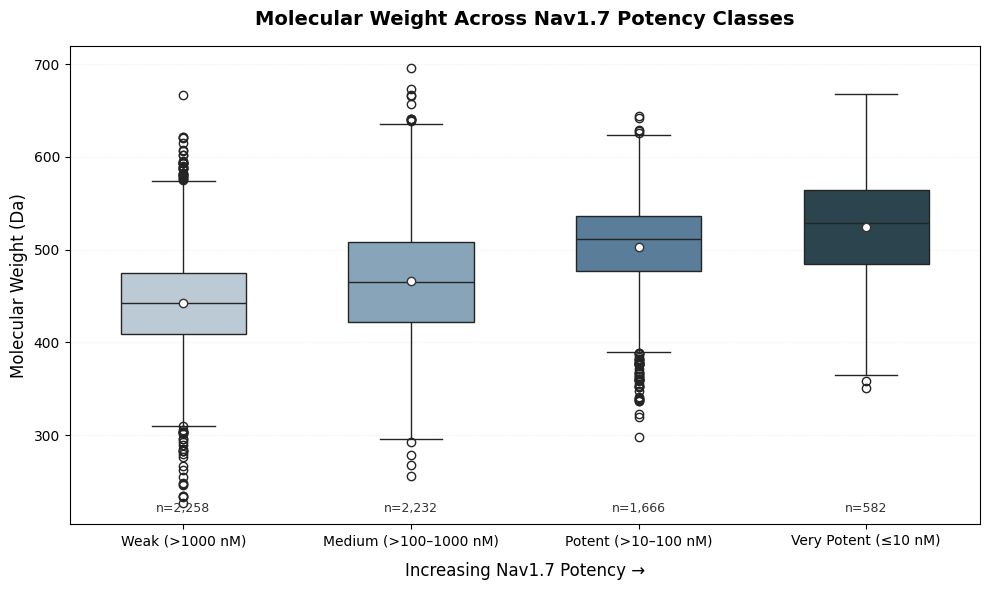

In [21]:
# Remove records missing molecular weight or potency classification
potency_mw_df = good_df.dropna(
    subset=['molecular_weight', 'potency_class']
).copy()

# Maintain the potency order defined previously
potency_order = [
    'Weak (>1000 nM)',
    'Medium (>100–1000 nM)',
    'Potent (>10–100 nM)',
    'Very Potent (≤10 nM)'
]

# Sequential blue palette: increasing potency
potency_colors = [
    '#B8CBD9',
    '#7FA6C0',
    '#4F7FA3',
    '#264653'
]

# Create box plot
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=potency_mw_df,
    x='potency_class',
    y='molecular_weight',
    order=potency_order,
    hue='potency_class',
    palette=dict(zip(potency_order, potency_colors)),
    legend=False,
    width=0.55,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#333333',
        'markersize': 6
    }
)

# Add sample size for each potency class
group_counts = (
    potency_mw_df['potency_class']
    .value_counts()
)

y_min, y_max = ax.get_ylim()

for i, category in enumerate(potency_order):
    count = group_counts.get(category, 0)

    ax.text(
        i,
        y_min + 10,
        f'n={count:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#333333'
    )

# Formatting
plt.title(
    'Molecular Weight Across Nav1.7 Potency Classes',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Increasing Nav1.7 Potency →',
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

In [22]:
# Calculate molecular-weight summary statistics by potency class
mw_summary_stats = (
    potency_mw_df
    .groupby('potency_class', observed=False)['molecular_weight']
    .describe(percentiles=[0.25, 0.50, 0.75])
)

print("--- Molecular Weight Summary by Potency Class ---")

for category in potency_order:
    row = mw_summary_stats.loc[category]

    median_val = row['50%']
    q25 = row['25%']
    q75 = row['75%']

    print(
        f"{category}: "
        f"median {median_val:.2f} Da, "
        f"IQR {q25:.2f}–{q75:.2f} Da"
    )

--- Molecular Weight Summary by Potency Class ---
Weak (>1000 nM): median 442.05 Da, IQR 409.09–475.10 Da
Medium (>100–1000 nM): median 465.18 Da, IQR 422.21–508.08 Da
Potent (>10–100 nM): median 511.13 Da, IQR 477.23–536.11 Da
Very Potent (≤10 nM): median 528.54 Da, IQR 484.03–563.81 Da


### Initial Observation

Molecular weight increases consistently across the four Nav1.7 potency classes. Median molecular weight rises from 442.05 Da for Weak compounds to 465.18 Da for Medium compounds, 511.13 Da for Potent compounds, and 528.54 Da for Very Potent compounds.

This progression is consistent with the moderate positive association observed between molecular weight and pIC₅₀ (Pearson r = 0.464; Spearman ρ = 0.468). In contrast to the LogP analysis, where median lipophilicity plateaued between the Potent and Very Potent classes, median molecular weight continues to increase in the Very Potent group.

The distributions nevertheless overlap substantially, indicating that molecular weight alone does not distinguish potency classes. The observed relationship is associative rather than causal and may reflect other structural features correlated with molecular size.

## 11. Relationship Between Molecular Weight and Lipophilicity

Because both molecular weight and calculated LogP are associated with Nav1.7 inhibitory potency, their relationship with each other is examined.

Pearson and Spearman correlations are calculated to assess linear and monotonic associations between molecular size and lipophilicity. Understanding this relationship is important because correlated molecular properties may contribute overlapping information in subsequent statistical and machine-learning analyses.

A linear regression line is included to visualize the overall trend.

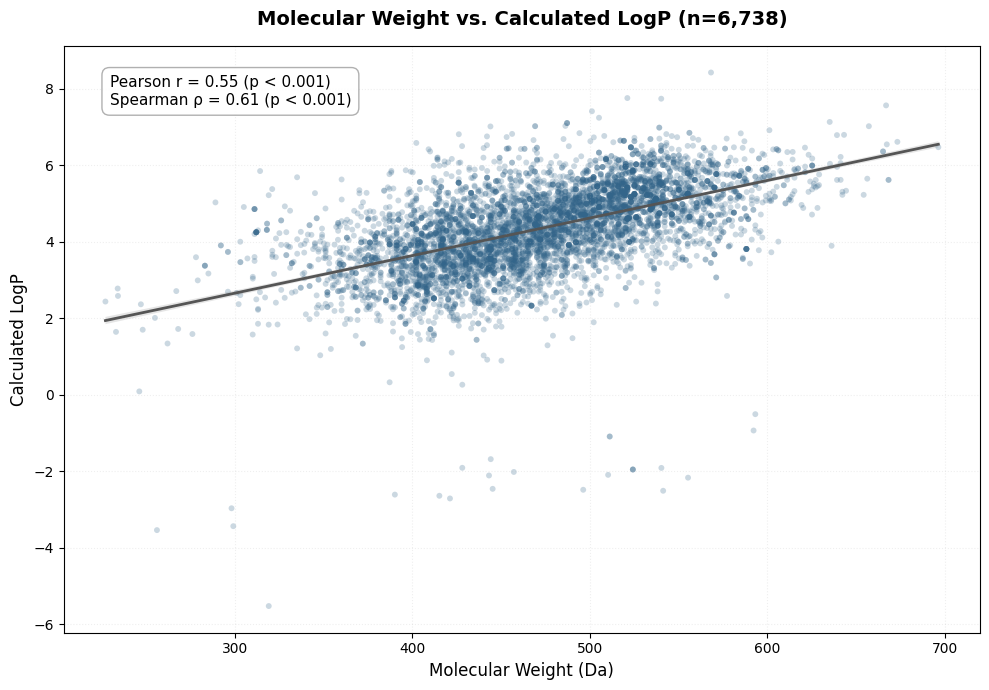

--- Molecular Weight vs. LogP Correlation ---
Pearson r:    0.552
Pearson p:    p < 0.001
Spearman ρ:   0.606
Spearman p:   p < 0.001


In [23]:
# Remove rows with missing molecular weight or LogP
mw_logp_df = good_df.dropna(
    subset=['molecular_weight', 'logp']
).copy()


# Calculate Pearson and Spearman correlations
pearson_r, p_pearson = stats.pearsonr(
    mw_logp_df['molecular_weight'],
    mw_logp_df['logp']
)

spearman_rho, p_spearman = stats.spearmanr(
    mw_logp_df['molecular_weight'],
    mw_logp_df['logp']
)


# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mw_logp_df,
    x='molecular_weight',
    y='logp',
    color='#33658A',
    alpha=0.25,
    edgecolor='none',
    s=18
)

# Add linear trend line
sns.regplot(
    data=mw_logp_df,
    x='molecular_weight',
    y='logp',
    scatter=False,
    color='#555555',
    line_kws={
        'linewidth': 2,
        'linestyle': '-'
    }
)


# Format p-values for display
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


# Add correlation statistics
stats_text = (
    f"Pearson r = {pearson_r:.2f} ({format_p(p_pearson)})\n"
    f"Spearman ρ = {spearman_rho:.2f} ({format_p(p_spearman)})"
)

plt.gca().text(
    0.05,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#A8A8A8'
    )
)


# Formatting
plt.title(
    f'Molecular Weight vs. Calculated LogP '
    f'(n={len(mw_logp_df):,})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=12
)

plt.ylabel(
    'Calculated LogP',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# Print numerical results
print("--- Molecular Weight vs. LogP Correlation ---")
print(f"Pearson r:    {pearson_r:.3f}")
print(f"Pearson p:    {format_p(p_pearson)}")
print(f"Spearman ρ:   {spearman_rho:.3f}")
print(f"Spearman p:   {format_p(p_spearman)}")

### Initial Observation

Molecular weight and calculated LogP are positively associated within the Nav1.7 dataset. Pearson correlation gives **r = 0.552**, while Spearman correlation gives **ρ = 0.606** (both p < 0.001).

The stronger Spearman correlation indicates that the relationship is somewhat better described as a general monotonic trend than as a strictly linear relationship. Overall, compounds with higher molecular weights tend to have higher calculated LogP values.

This relationship is important when interpreting their individual associations with Nav1.7 potency. Molecular weight and LogP are not independent molecular properties in this dataset, so their separate correlations with pIC₅₀ may reflect partially overlapping structural information.

Nevertheless, the two properties show different patterns across potency classes. Median molecular weight continues to increase from Weak through Very Potent compounds, whereas median LogP increases through the Potent class and then plateaus slightly in the Very Potent class. This suggests that the relationships among molecular size, lipophilicity, and Nav1.7 potency are more complex than a single linear property–activity relationship.

## 12. Combined Association of Molecular Weight and LogP with Potency

Molecular weight and calculated LogP are both positively associated with Nav1.7 inhibitory potency, but they are also correlated with each other. A multiple linear regression is therefore used to examine their simultaneous relationships with pIC₅₀.

The model takes the form:

**pIC₅₀ = β₀ + β₁(Molecular Weight) + β₂(LogP)**

This analysis evaluates whether each property retains an association with pIC₅₀ when the other is included in the same model.

The regression is used here as an exploratory statistical analysis rather than as a predictive QSAR model. More comprehensive molecular descriptors and machine-learning approaches are evaluated separately in `03_machine_learning_models.ipynb`.

In [24]:
# Prepare complete cases for multiple linear regression
regression_df = good_df[
    ['pIC50', 'molecular_weight', 'logp']
].dropna().copy()

# Define response and predictor variables
y = regression_df['pIC50']

X = regression_df[
    ['molecular_weight', 'logp']
]

# Add intercept
X = sm.add_constant(X)

# Fit multiple linear regression
mlr_model = sm.OLS(y, X).fit()

# Extract coefficients
b0 = mlr_model.params['const']
b_mw = mlr_model.params['molecular_weight']
b_logp = mlr_model.params['logp']


# Display fitted equation
print("--- Multiple Linear Regression Equation ---")

print(
    f"pIC₅₀ = {b0:.3f} "
    f"+ ({b_mw:.5f} × MW) "
    f"+ ({b_logp:.3f} × LogP)"
)


# Display model statistics
print("\n--- Regression Summary ---")

print(mlr_model.summary())

--- Multiple Linear Regression Equation ---
pIC₅₀ = 2.879 + (0.00664 × MW) + (0.114 × LogP)

--- Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                  pIC50   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     980.4
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:26:19   Log-Likelihood:                -8908.5
No. Observations:                6738   AIC:                         1.782e+04
Df Residuals:                    6735   BIC:                         1.784e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----

### Initial Observation

When molecular weight and calculated LogP are included simultaneously in a multiple linear regression, both properties retain positive associations with Nav1.7 inhibitory potency.

The fitted relationship is:

**pIC₅₀ = 2.879 + 0.00664(MW) + 0.114(LogP)**

Both molecular weight and LogP coefficients are statistically significant (p < 0.001). Holding LogP constant, greater molecular weight is associated with higher pIC₅₀; holding molecular weight constant, greater LogP is also associated with higher pIC₅₀.

The model has an **R² of 0.225**, indicating that molecular weight and LogP together account for approximately 22.5% of the observed variation in pIC₅₀. Most of the variation therefore remains unexplained by these two general physicochemical properties.

These results support the idea that molecular size and lipophilicity are relevant to Nav1.7 inhibitory activity but are insufficient to describe potency on their own. More detailed structural and molecular descriptors are needed to capture additional structure–activity relationships, motivating the multivariable machine-learning analysis developed in `03_machine_learning_models.ipynb`.

## 13. Expanded Molecular Descriptor Set

The initial exploratory analysis focused on molecular weight and LogP. To characterize additional structural and physicochemical properties that may contribute to Nav1.7 inhibitory activity, a broader set of interpretable RDKit descriptors is calculated from each compound's canonical SMILES.

The selected descriptors are:

- **Molecular Weight:** molecular size
- **LogP:** calculated lipophilicity
- **TPSA:** topological polar surface area
- **HBA:** hydrogen-bond acceptors
- **HBD:** hydrogen-bond donors
- **Rotatable Bonds:** molecular flexibility
- **Ring Count:** total number of rings
- **Aromatic Rings:** number of aromatic rings
- **Fraction Csp3:** fraction of carbon atoms with sp³ hybridization
- **Heavy Atoms:** number of non-hydrogen atoms
- **Heteroatoms:** number of non-carbon, non-hydrogen atoms

These descriptors were selected because they provide chemically interpretable representations of molecular size, lipophilicity, polarity, hydrogen bonding, flexibility, ring structure, and molecular composition.

The expanded descriptor set will be examined for relationships and redundancy before being used in subsequent machine-learning analysis.

In [25]:
# Define the selected molecular descriptors
descriptor_names = [
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]


def calculate_descriptors(smiles):
    """Calculate selected RDKit descriptors from a SMILES string."""

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series(
            {name: np.nan for name in descriptor_names}
        )

    return pd.Series({
        'MW': Descriptors.ExactMolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'RingCount': Descriptors.RingCount(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'Heteroatoms': Descriptors.NumHeteroatoms(mol)
    })


print("Calculating molecular descriptors...")

descriptor_df = (
    good_df['canonical_smiles']
    .apply(calculate_descriptors)
)

print("Descriptor calculation complete.")

Calculating molecular descriptors...
Descriptor calculation complete.


In [26]:
# Remove earlier MW and LogP columns before attaching
# the standardized descriptor matrix
base_df = good_df.drop(
    columns=['molecular_weight', 'logp'],
    errors='ignore'
).reset_index(drop=True)

analysis_df = pd.concat(
    [
        base_df,
        descriptor_df.reset_index(drop=True)
    ],
    axis=1
)

print(f"Analysis dataset created: {len(analysis_df):,} compounds")

Analysis dataset created: 6,738 compounds


In [27]:
# Check descriptor calculation completeness
missing_descriptors = (
    analysis_df[descriptor_names]
    .isna()
    .sum()
)

print("--- Descriptor Calculation Validation ---")
print(f"Total compounds: {len(analysis_df):,}")

print("\nMissing values by descriptor:")
print(missing_descriptors)

print("\n--- Descriptor Range Overview ---")

display(
    analysis_df[descriptor_names]
    .describe()
    .loc[['min', '50%', 'max']]
    .T
    .rename(columns={
        'min': 'Minimum',
        '50%': 'Median',
        'max': 'Maximum'
    })
)

--- Descriptor Calculation Validation ---
Total compounds: 6,738

Missing values by descriptor:
MW                0
LogP              0
TPSA              0
HBA               0
HBD               0
RotatableBonds    0
RingCount         0
AromaticRings     0
FractionCSP3      0
HeavyAtoms        0
Heteroatoms       0
dtype: int64

--- Descriptor Range Overview ---


,Minimum,Median,Maximum
MW,227.109233,472.072635,696.23581
LogP,-5.519800,4.404800,8.42150
TPSA,15.270000,94.070000,215.23000
HBA,2.000000,6.000000,12.00000
HBD,0.000000,1.000000,9.00000
RotatableBonds,1.000000,6.000000,22.00000
RingCount,1.000000,4.000000,8.00000
AromaticRings,0.000000,3.000000,6.00000
FractionCSP3,0.000000,0.190476,1.00000
HeavyAtoms,15.000000,32.000000,48.00000


### Descriptor Validation

All 6,738 GOOD-quality compounds were successfully characterized using the 11 selected molecular descriptors, with no missing descriptor values.

The descriptor ranges indicate substantial chemical diversity across molecular size, lipophilicity, polarity, hydrogen-bonding capacity, flexibility, ring composition, and carbon hybridization. Molecular weight and LogP values are consistent with those obtained during the earlier exploratory analyses.

The complete descriptor matrix can therefore be used for subsequent analysis of relationships among molecular properties and Nav1.7 inhibitory activity.

## 14. Correlation Structure of Molecular Descriptors

To examine relationships among the selected molecular descriptors and Nav1.7 inhibitory potency, a Pearson correlation matrix is calculated for pIC₅₀ and the 11 molecular descriptors.

This analysis serves two purposes:

1. To identify molecular properties that show linear associations with pIC₅₀.
2. To identify strongly correlated descriptors that may contain overlapping structural or physicochemical information.

Understanding descriptor redundancy is important before constructing multivariable machine-learning models, since several molecular descriptors may encode related chemical characteristics.

In [28]:
# Define analysis variables with pIC₅₀ first
correlation_features = [
    'pIC50',
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]

# Calculate Pearson correlation matrix
correlation_matrix = (
    analysis_df[correlation_features]
    .corr(method='pearson')
)

print("--- Pearson Correlation Matrix ---")

display(
    correlation_matrix.round(2)
)

--- Pearson Correlation Matrix ---


,pIC50,MW,LogP,TPSA,HBA,HBD,RotatableBonds,RingCount,AromaticRings,FractionCSP3,HeavyAtoms,Heteroatoms
pIC50,1.00,0.46,0.34,0.15,0.12,0.06,0.25,0.20,0.07,0.06,0.36,0.33
MW,0.46,1.00,0.55,0.45,0.46,-0.00,0.50,0.34,0.41,-0.12,0.92,0.76
LogP,0.34,0.55,1.00,-0.13,0.04,-0.38,0.20,0.21,0.51,-0.33,0.49,0.21
TPSA,0.15,0.45,-0.13,1.00,0.76,0.47,0.40,0.00,0.34,-0.35,0.40,0.60
HBA,0.12,0.46,0.04,0.76,1.00,0.20,0.39,0.07,0.39,-0.33,0.36,0.63
HBD,0.06,-0.00,-0.38,0.47,0.20,1.00,0.24,-0.26,-0.21,0.06,-0.02,0.12
RotatableBonds,0.25,0.50,0.20,0.40,0.39,0.24,1.00,-0.04,0.07,0.09,0.47,0.32
RingCount,0.20,0.34,0.21,0.00,0.07,-0.26,-0.04,1.00,0.38,0.07,0.47,0.03
AromaticRings,0.07,0.41,0.51,0.34,0.39,-0.21,0.07,0.38,1.00,-0.80,0.48,0.25
FractionCSP3,0.06,-0.12,-0.33,-0.35,-0.33,0.06,0.09,0.07,-0.80,1.00,-0.12,-0.20


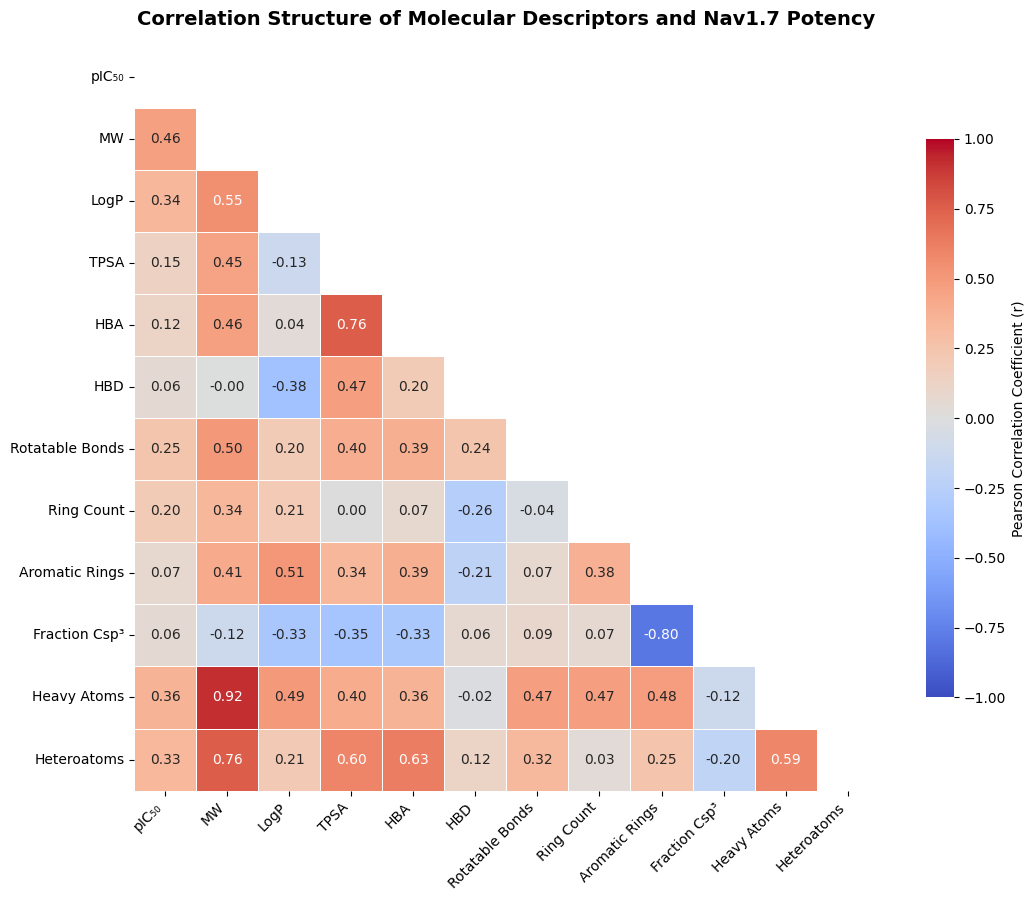

In [29]:
# Create a mask for the redundant upper triangle
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

# Display labels for publication-quality presentation
display_labels = [
    'pIC₅₀',
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'Rotatable Bonds',
    'Ring Count',
    'Aromatic Rings',
    'Fraction Csp³',
    'Heavy Atoms',
    'Heteroatoms'
]

# Create correlation heatmap
plt.figure(figsize=(11, 9))

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        'label': 'Pearson Correlation Coefficient (r)',
        'shrink': 0.75
    }
)

# Apply chemistry-readable display labels
ax.set_xticklabels(
    display_labels,
    rotation=45,
    ha='right',
    fontsize=10
)

ax.set_yticklabels(
    display_labels,
    rotation=0,
    fontsize=10
)

plt.title(
    'Correlation Structure of Molecular Descriptors and Nav1.7 Potency',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

### Initial Observation

The correlation matrix reveals that the selected molecular descriptors contain both complementary and overlapping chemical information.

Among the individual descriptors, molecular weight shows the strongest linear association with pIC₅₀ (**r = 0.46**), followed by Heavy Atoms (**r = 0.36**), LogP (**r = 0.34**), and Heteroatoms (**r = 0.33**). The remaining descriptors show weaker individual linear associations with potency. No single descriptor strongly explains Nav1.7 inhibitory activity, supporting the need for a multivariable approach.

Several strong correlations are also present among the molecular descriptors. Molecular weight and Heavy Atoms are particularly strongly correlated (**r = 0.92**), indicating substantial redundancy in their representation of molecular size. TPSA and HBA are also strongly correlated (**r = 0.76**), while Aromatic Rings and Fraction Csp³ show a strong inverse relationship (**r = −0.80**).

These relationships indicate that some descriptors encode overlapping aspects of molecular structure. Descriptor redundancy should therefore be considered when constructing and interpreting subsequent machine-learning models.

## 15. Multicollinearity Audit Using Variance Inflation Factors

The Pearson correlation matrix revealed substantial relationships among several molecular descriptors. Because pairwise correlations do not capture multivariable redundancy, Variance Inflation Factors (VIFs) were calculated for the 11 molecular descriptors.

VIF measures how strongly the variance of one predictor is explained by the remaining predictors. Higher VIF values indicate greater multicollinearity and potential redundancy among descriptors.

Common interpretive guidelines are:

- **VIF < 5:** relatively low multicollinearity
- **VIF 5–10:** substantial multicollinearity
- **VIF > 10:** strong multicollinearity

VIF is used here as a diagnostic of descriptor redundancy rather than as an automatic criterion for feature removal. Its implications for predictive modeling are considered separately in the machine-learning analysis.

In [31]:
# Candidate molecular descriptors
candidate_descriptors = [
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]

# Extract complete descriptor matrix
X_vif = analysis_df[candidate_descriptors].dropna().copy()

# Add intercept for VIF calculation
X_vif_const = sm.add_constant(X_vif)

# Calculate VIF for each molecular descriptor
vif_data = pd.DataFrame({
    'Descriptor': candidate_descriptors,
    'VIF': [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(1, X_vif_const.shape[1])
    ]
})

# Sort from highest to lowest VIF
vif_data = vif_data.sort_values(
    'VIF',
    ascending=False
).reset_index(drop=True)

print("--- Multicollinearity Audit: Variance Inflation Factors (VIF) ---")
print(
    vif_data.to_string(
        index=False,
        formatters={'VIF': '{:.2f}'.format}
    )
)

--- Multicollinearity Audit: Variance Inflation Factors (VIF) ---
    Descriptor   VIF
            MW 21.15
    HeavyAtoms 11.41
 AromaticRings  9.71
  FractionCSP3  7.49
   Heteroatoms  5.69
          TPSA  5.06
          LogP  3.82
           HBA  3.41
     RingCount  2.70
RotatableBonds  2.10
           HBD  1.82


## 16. Principal Component Analysis of Chemical Space

The 11 molecular descriptors describe different but partially correlated aspects of molecular structure and physicochemical properties. Principal Component Analysis (PCA) is used to summarize this multidimensional descriptor space and visualize the overall chemical diversity of the Nav1.7 dataset.

Because the descriptors are measured on different numerical scales, all descriptors are standardized to zero mean and unit variance before PCA. PCA is then performed using only the molecular descriptors; pIC₅₀ is not included in the PCA calculation.

The first two principal components are used to generate a two-dimensional representation of chemical space. Compounds are colored by potency class after projection to examine whether compounds with different Nav1.7 inhibitory potencies occupy distinct or overlapping regions of descriptor space.

In [33]:
# Define molecular descriptors used for PCA
pca_features = [
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]

# Prepare complete PCA dataset
pca_df = analysis_df.dropna(
    subset=pca_features + ['pIC50']
).copy()


# Standardize descriptors before PCA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    pca_df[pca_features]
)


# Fit PCA and project compounds onto the first two components
pca = PCA(n_components=2)

pca_scores = pca.fit_transform(X_scaled)

pca_df['PC1'] = pca_scores[:, 0]
pca_df['PC2'] = pca_scores[:, 1]


# Calculate explained variance
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100

total_variance = pc1_variance + pc2_variance

print("--- PCA Explained Variance ---")
print(f"PC1: {pc1_variance:.1f}%")
print(f"PC2: {pc2_variance:.1f}%")
print(f"PC1 + PC2: {total_variance:.1f}%")

--- PCA Explained Variance ---
PC1: 39.5%
PC2: 20.1%
PC1 + PC2: 59.6%


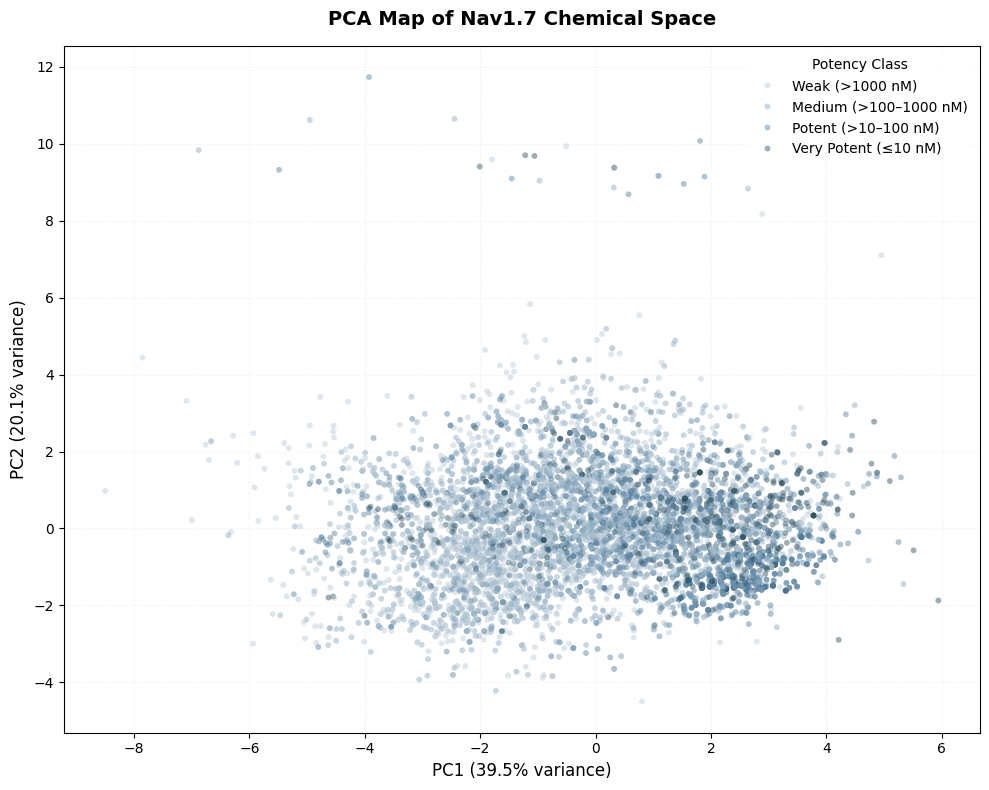

In [34]:
# Potency class order
potency_order = [
    'Weak (>1000 nM)',
    'Medium (>100–1000 nM)',
    'Potent (>10–100 nM)',
    'Very Potent (≤10 nM)'
]

# Professional potency gradient used throughout the notebook
potency_colors = [
    '#B8C9D6',
    '#89A9BF',
    '#557F9E',
    '#294C5A'
]


# Create 2D PCA chemical-space map
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='potency_class',
    hue_order=potency_order,
    palette=potency_colors,
    alpha=0.45,
    edgecolor='none',
    s=18
)

plt.title(
    'PCA Map of Nav1.7 Chemical Space',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    f'PC1 ({pc1_variance:.1f}% variance)',
    fontsize=12
)

plt.ylabel(
    f'PC2 ({pc2_variance:.1f}% variance)',
    fontsize=12
)

plt.grid(
    True,
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    title='Potency Class',
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

plt.tight_layout()
plt.show()

### Initial Observation

The first two principal components explain **59.6% of the total variance** in the standardized molecular descriptor space, with PC1 accounting for **39.5%** and PC2 accounting for **20.1%**.

The four potency classes occupy substantially overlapping regions of the PCA chemical space, indicating that the selected physicochemical descriptors do not separate Nav1.7 potency into distinct clusters along the two dominant directions of chemical variation. A gradual shift toward more potent compounds is nevertheless visible along PC1.

Because PCA is unsupervised and does not use pIC₅₀ when determining the principal components, this overlap does not imply that the descriptors lack predictive information. Rather, the dominant sources of chemical variation are not equivalent to the directions that best distinguish inhibitory potency.

Interpretation of the chemical meaning of PC1 and PC2 requires examination of the PCA descriptor loadings.

### PCA Descriptor Loadings

To interpret the chemical meaning of the principal components, the descriptor loadings for PC1 and PC2 are examined.

Each loading represents the contribution of a standardized molecular descriptor to a principal component. Larger absolute loading values indicate that a descriptor contributes more strongly to that component, while the sign indicates the direction of the relationship.

Because the sign of a principal component is mathematically arbitrary, interpretation focuses primarily on the relative magnitudes and patterns of the loadings rather than on the sign alone.

In [35]:
# Extract loadings from the fitted PCA model
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=['PC1', 'PC2']
)

# Add absolute loadings for ranking
loadings_df['|PC1|'] = loadings_df['PC1'].abs()
loadings_df['|PC2|'] = loadings_df['PC2'].abs()

# Sort by contribution to PC1
loadings_by_pc1 = loadings_df.sort_values(
    '|PC1|',
    ascending=False
)

print("--- PCA Loadings: Ranked by PC1 Contribution ---")

display(
    loadings_by_pc1[
        ['PC1', 'PC2']
    ].round(3)
)

--- PCA Loadings: Ranked by PC1 Contribution ---


,PC1,PC2
MW,0.426,-0.056
HeavyAtoms,0.404,-0.116
Heteroatoms,0.371,0.172
HBA,0.343,0.260
TPSA,0.331,0.382
AromaticRings,0.319,-0.309
RotatableBonds,0.253,0.225
LogP,0.236,-0.432
FractionCSP3,-0.210,0.159
RingCount,0.153,-0.326


In [36]:
# Sort separately by contribution to PC2
loadings_by_pc2 = loadings_df.sort_values(
    '|PC2|',
    ascending=False
)

print("--- PCA Loadings: Ranked by PC2 Contribution ---")

display(
    loadings_by_pc2[
        ['PC1', 'PC2']
    ].round(3)
)

--- PCA Loadings: Ranked by PC2 Contribution ---


,PC1,PC2
HBD,0.035,0.526
LogP,0.236,-0.432
TPSA,0.331,0.382
RingCount,0.153,-0.326
AromaticRings,0.319,-0.309
HBA,0.343,0.260
RotatableBonds,0.253,0.225
Heteroatoms,0.371,0.172
FractionCSP3,-0.210,0.159
HeavyAtoms,0.404,-0.116


### Interpretation of Principal Components

PC1, which explains **39.5%** of the standardized descriptor variance, is driven primarily by molecular weight, heavy-atom count, heteroatom count, hydrogen-bond acceptors, TPSA, and aromatic-ring count. PC1 can therefore be interpreted broadly as an axis of **molecular size and structural complexity**, with additional contributions from heteroatom content and polarity.

PC2 explains an additional **20.1%** of the variance and is driven most strongly by hydrogen-bond donors, LogP, TPSA, ring count, and aromatic-ring count. Higher PC2 values are associated with greater hydrogen-bonding and polar character, whereas lower PC2 values are associated with greater lipophilicity and ring content. PC2 therefore broadly distinguishes **polar/hydrogen-bonding character from more lipophilic and ring-rich molecular character**.

Together, PC1 and PC2 explain **59.6%** of the total standardized descriptor variance. The tendency of more potent compounds to occur toward positive PC1 is consistent with earlier observations that molecular weight, heavy-atom count, and heteroatom count are positively associated with pIC₅₀. However, the substantial overlap among potency classes indicates that these dominant directions of chemical variation do not independently separate Nav1.7 inhibitory potency.

## 17. Exploratory Analysis Summary

Exploratory analysis of the 6,738 GOOD-quality Nav1.7 compounds revealed several patterns in the relationship between molecular properties and inhibitory potency.

The pIC₅₀ distribution spans a broad activity range, indicating that the dataset contains compounds from weak to highly potent Nav1.7 inhibitors. Molecular weight and calculated LogP also cover substantial chemical ranges, although much of the dataset is concentrated around moderately large and lipophilic compounds.

Among the individual molecular descriptors examined, molecular weight showed the strongest linear association with pIC₅₀ (Pearson r = 0.46), followed by heavy-atom count (r = 0.36), LogP (r = 0.34), and heteroatom count (r = 0.33). These relationships indicate measurable associations between physicochemical properties and Nav1.7 inhibitory potency, but no single descriptor provides a strong explanation of activity.

The descriptor correlation analysis also revealed substantial redundancy within the molecular feature space. In particular, molecular weight and heavy-atom count were strongly correlated (r = 0.92), while aromatic-ring count and FractionCSP3 showed a strong inverse relationship (r = −0.80). VIF analysis provided an additional assessment of multivariable descriptor redundancy.

Principal Component Analysis further summarized the multidimensional chemical space. PC1 and PC2 explained 39.5% and 20.1% of the standardized descriptor variance, respectively, for a combined 59.6%. PC1 primarily represented molecular size and structural complexity, whereas PC2 broadly distinguished polar and hydrogen-bonding character from more lipophilic and ring-rich molecular character. Potency classes showed substantial overlap in PCA space, indicating that the dominant directions of chemical variation do not independently separate Nav1.7 inhibitory potency.

Overall, the exploratory results suggest that Nav1.7 potency is associated with multiple interacting molecular properties rather than being determined by any single simple physicochemical descriptor. The complete molecular descriptor dataset is therefore carried forward to `03_machine_learning_models.ipynb`, where multivariable predictive models will be developed and evaluated.

## 18. Export Dataset for Machine-Learning Analysis

The validated analysis dataset containing compound identifiers, Nav1.7 inhibitory activity, potency classifications, data-quality information, and the 11 standardized molecular descriptors is exported for use in `03_machine_learning_models.ipynb`.

Exporting the prepared dataset at this stage creates a reproducible boundary between exploratory analysis and predictive modeling and avoids recalculating molecular descriptors in subsequent notebooks.

In [41]:
# Define the final column order for the modeling dataset
export_columns = [
    # Compound identity
    'molecule_chembl_id',
    'canonical_smiles',

    # Biological activity
    'ic50_nm',
    'pIC50',

    # Measurement and data-quality information
    'min_val',
    'max_val',
    'measurement_count',
    'max_min_ratio',
    'data_quality',
    'confidence_level',
    'potency_class',

    # Molecular descriptors
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]

# Create final dataset for downstream modeling
modeling_df = analysis_df[export_columns].copy()

# Final validation
print("--- Final Modeling Dataset ---")
print(f"Compounds:            {len(modeling_df):,}")
print(f"Columns:              {len(modeling_df.columns)}")
print(f"Duplicate structures: {modeling_df['canonical_smiles'].duplicated().sum():,}")
print(f"Missing values:       {modeling_df.isna().sum().sum():,}")

display(modeling_df.head())

--- Final Modeling Dataset ---
Compounds:            6,738
Columns:              22
Duplicate structures: 0
Missing values:       0


,molecule_chembl_id,canonical_smiles,ic50_nm,pIC50,min_val,max_val,measurement_count,max_min_ratio,data_quality,confidence_level,...,LogP,TPSA,HBA,HBD,RotatableBonds,RingCount,AromaticRings,FractionCSP3,HeavyAtoms,Heteroatoms
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,990.0,6.004365,990.0,990.0,1,1.000000,GOOD,LOW,...,2.2237,92.27,7.0,2.0,6.0,4.0,3.0,0.181818,30.0,8.0
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,6.0,8.221849,6.0,6.0,1,1.000000,GOOD,LOW,...,4.1343,75.71,4.0,1.0,7.0,6.0,1.0,0.625000,32.0,8.0
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,1820.0,5.739929,1820.0,1820.0,1,1.000000,GOOD,LOW,...,5.8465,40.46,2.0,2.0,6.0,2.0,1.0,0.523810,23.0,2.0
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,2420.0,5.616185,2420.0,2420.0,1,1.000000,GOOD,LOW,...,4.5075,71.53,6.0,1.0,5.0,4.0,3.0,0.150000,28.0,8.0
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,51.1,7.291579,51.0,51.2,2,1.003922,GOOD,MEDIUM,...,3.7291,85.59,5.0,1.0,6.0,6.0,2.0,0.619048,29.0,8.0


In [42]:
# Export the completed EDA dataset
output_file = 'nav17_good_modeling_dataset.csv'

modeling_df.to_csv(output_file, index=False)

print(f"Saved: {output_file}")
print(
    f"Dataset dimensions: "
    f"{modeling_df.shape[0]:,} rows × {modeling_df.shape[1]} columns"
)

# Download from Google Colab
from google.colab import files
files.download(output_file)

Saved: nav17_good_modeling_dataset.csv
Dataset dimensions: 6,738 rows × 22 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>